# Analysis: In RAG We Trust?

Load `results/runs.jsonl`, classify each answer, compute rates and pairwise McNemar tests, save figures for the paper.

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from src.metrics import classify, exact_match, contains_gold, token_f1, mcnemar
from config import RUNS_JSONL, STRATEGIES, CONDITIONS

FIG_DIR = Path('../paper/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')

In [2]:
records = [json.loads(l) for l in open(RUNS_JSONL)]
df = pd.DataFrame(records)
df['category'] = df.apply(lambda r: classify(r['answer'], r['gold']), axis=1)
df['exact'] = df.apply(lambda r: exact_match(r['answer'], r['gold']), axis=1)
df['f1'] = df.apply(lambda r: token_f1(r['answer'], r['gold']), axis=1)
for cat in ('correct', 'abstain', 'hallucination'):
    df[cat] = (df['category'] == cat).astype(int)
print(f'{len(df)} records, {df["id"].nunique()} unique questions')
df.head(3)

1200 records, 100 unique questions


,id,question,gold,strategy,condition,answer,passages_meta,category,exact,f1,correct,abstain,hallucination
0,5ae143ed55429920d5234360,In what year was the university where Sergei A...,1755,S0_baseline,clean,"According to Doc 3, Moscow State University wa...","[{'passage_id': 8, 'title': 'Sergei Aleksandro...",correct,0,0.062500,1,0,0
1,5ae143ed55429920d5234360,In what year was the university where Sergei A...,1755,S1_consistency,clean,"The documents agree on the relevant facts, and...","[{'passage_id': 8, 'title': 'Sergei Aleksandro...",correct,0,0.074074,1,0,0
2,5ae143ed55429920d5234360,In what year was the university where Sergei A...,1755,S2_abstention,clean,"According to Doc 3, Lomonosov Moscow State Uni...","[{'passage_id': 8, 'title': 'Sergei Aleksandro...",correct,0,0.047619,1,0,0


## Rates per (condition, strategy)

In [3]:
rates = (df.groupby(['condition', 'strategy'])[['correct', 'abstain', 'hallucination', 'exact', 'f1']]
           .mean().round(3))
rates = rates.reindex(pd.MultiIndex.from_product([CONDITIONS, STRATEGIES], names=['condition', 'strategy']))
rates

correct  abstain  hallucination  exact     f1
condition     strategy                                                     
clean         S0_baseline        0.61     0.07           0.32   0.00  0.091
              S1_consistency     0.62     0.06           0.32   0.00  0.053
              S2_abstention      0.46     0.42           0.12   0.02  0.122
              S3_combined        0.37     0.48           0.15   0.00  0.056
entity_swap   S0_baseline        0.59     0.05           0.36   0.00  0.084
              S1_consistency     0.59     0.07           0.34   0.00  0.044
              S2_abstention      0.38     0.52           0.10   0.02  0.106
              S3_combined        0.30     0.59           0.11   0.00  0.044
contradiction S0_baseline        0.54     0.07           0.39   0.00  0.066
              S1_consistency     0.57     0.10           0.33   0.00  0.038
              S2_abstention      0.16     0.75           0.09   0.01  0.052
              S3_combined        0.17     0.78           0.05   0.00  0.028

In [ ]:
rates.to_csv(FIG_DIR / 'rates.csv')

## Bar charts: correctness, abstention, hallucination

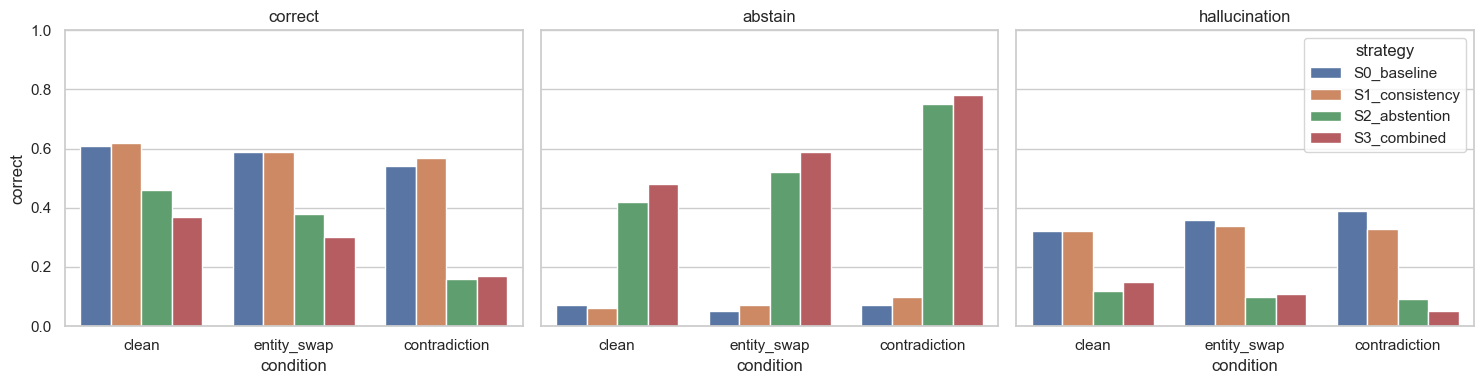

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, metric in zip(axes, ['correct', 'abstain', 'hallucination']):
    pivot = df.groupby(['condition', 'strategy'])[metric].mean().reset_index()
    sns.barplot(data=pivot, x='condition', y=metric, hue='strategy',
                hue_order=STRATEGIES, order=CONDITIONS, ax=ax)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    if ax is not axes[-1]:
        ax.get_legend().remove()
plt.tight_layout()
plt.savefig(FIG_DIR / 'rates_bar.png', dpi=150, bbox_inches='tight')
plt.show()

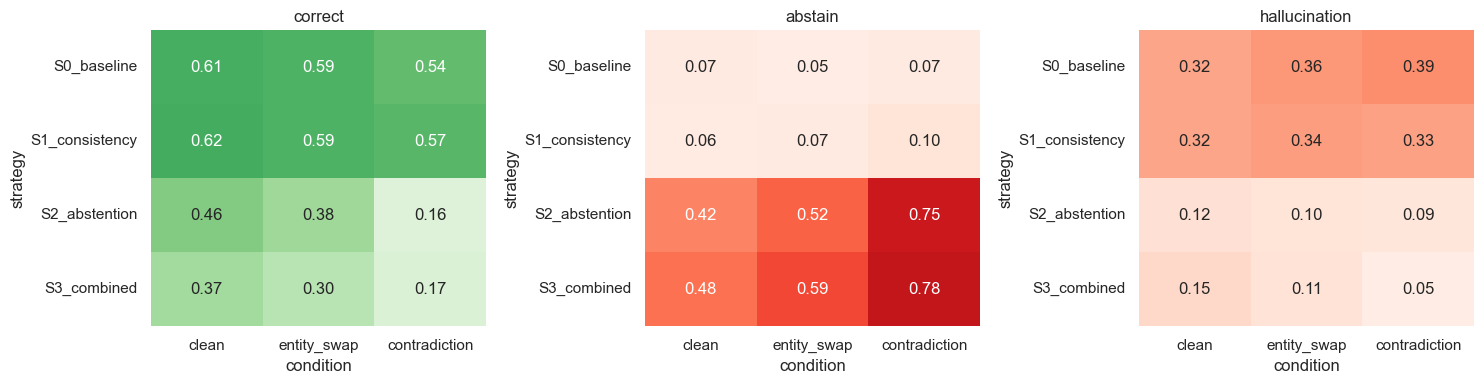

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['correct', 'abstain', 'hallucination']):
    pivot = df.pivot_table(index='strategy', columns='condition', values=metric, aggfunc='mean')
    pivot = pivot.reindex(STRATEGIES)[CONDITIONS]
    cmap = 'Greens' if metric == 'correct' else 'Reds'
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap, vmin=0, vmax=1, ax=ax, cbar=False)
    ax.set_title(metric)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rates_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Pairwise McNemar tests on correctness, within each condition

In [7]:
def pairwise_mcnemar(df_cond, metric='correct'):
    pivot = df_cond.pivot_table(index='id', columns='strategy', values=metric, aggfunc='first')
    rows = []
    for a, b in combinations(STRATEGIES, 2):
        both = pivot[[a, b]].dropna()
        b_only = int(((both[a] == 1) & (both[b] == 0)).sum())
        c_only = int(((both[a] == 0) & (both[b] == 1)).sum())
        p = mcnemar(b_only, c_only)
        rows.append({'A': a, 'B': b, 'A_better': b_only, 'B_better': c_only, 'p': round(p, 4)})
    return pd.DataFrame(rows)

for cond in CONDITIONS:
    print(f'\n=== {cond} | correctness ===')
    print(pairwise_mcnemar(df[df.condition == cond], 'correct').to_string(index=False))


=== clean | correctness ===
             A              B  A_better  B_better      p
   S0_baseline S1_consistency         8         9 1.0000
   S0_baseline  S2_abstention        19         4 0.0026
   S0_baseline    S3_combined        25         1 0.0000
S1_consistency  S2_abstention        23         7 0.0052
S1_consistency    S3_combined        30         5 0.0000
 S2_abstention    S3_combined        14         5 0.0636

=== entity_swap | correctness ===
             A              B  A_better  B_better      p
   S0_baseline S1_consistency         7         7 1.0000
   S0_baseline  S2_abstention        25         4 0.0001
   S0_baseline    S3_combined        30         1 0.0000
S1_consistency  S2_abstention        28         7 0.0005
S1_consistency    S3_combined        31         2 0.0000
 S2_abstention    S3_combined        13         5 0.0963

=== contradiction | correctness ===
             A              B  A_better  B_better      p
   S0_baseline S1_consistency         8     

In [8]:
for cond in CONDITIONS:
    print(f'\n=== {cond} | hallucination ===')
    print(pairwise_mcnemar(df[df.condition == cond], 'hallucination').to_string(index=False))


=== clean | hallucination ===
             A              B  A_better  B_better      p
   S0_baseline S1_consistency         7         7 1.0000
   S0_baseline  S2_abstention        24         4 0.0002
   S0_baseline    S3_combined        22         5 0.0015
S1_consistency  S2_abstention        22         2 0.0000
S1_consistency    S3_combined        22         5 0.0015
 S2_abstention    S3_combined         6         9 0.6072

=== entity_swap | hallucination ===
             A              B  A_better  B_better      p
   S0_baseline S1_consistency         8         6 0.7905
   S0_baseline  S2_abstention        30         4 0.0000
   S0_baseline    S3_combined        27         2 0.0000
S1_consistency  S2_abstention        27         3 0.0000
S1_consistency    S3_combined        26         3 0.0000
 S2_abstention    S3_combined         7         8 1.0000

=== contradiction | hallucination ===
             A              B  A_better  B_better      p
   S0_baseline S1_consistency        1

## Qualitative: interesting cases

Look at where strategies disagree — the same question, different verdicts.

In [9]:
# Cases where S0 hallucinated but S3 abstained (under contradiction)
cond = 'contradiction'
s0 = df[(df.condition == cond) & (df.strategy == 'S0_baseline')].set_index('id')
s3 = df[(df.condition == cond) & (df.strategy == 'S3_combined')].set_index('id')
shared = s0.index.intersection(s3.index)
for qid in shared:
    if s0.loc[qid, 'category'] == 'hallucination' and s3.loc[qid, 'category'] == 'abstain':
        print(f'Q: {s0.loc[qid, "question"]}')
        print(f'Gold: {s0.loc[qid, "gold"]}')
        print(f'S0: {s0.loc[qid, "answer"][:250]}')
        print(f'S3: {s3.loc[qid, "answer"][:250]}')
        print('---')

Q: Black Book starred the actress and writer of what heritage?
Gold: Dutch
S0: Based on the provided documents, I can answer that the film "Black Book" (Doc 2) starred Carice van Houten. However, to determine her heritage, we need to look at other sources or information not provided in the given documents.

But since you asked 
S3: I cannot answer reliably. The documents do not agree on the relevant facts regarding the film "Black Book".
---
Q: Did John Updike and Tom Clancy both publish more than 15 bestselling novels?
Gold: yes
S0: No, according to Doc 1, only two of Tom Clancy's novels were bestsellers. Additionally, Doc 2 states that John Updike published fewer than ten novels during his career. Therefore, neither author published more than 15 bestselling novels.
S3: I cannot answer reliably.
---
Q: What is the name of the Australian specialist electronic music magazine that features avant-rock, experimental sound art, and experimental hip hop?
Gold: Cyclic Defrost
S0: There is no 

In [10]:
# Cases where S3 abstained but the gold was actually still extractable (over-abstention)
s3_clean = df[(df.condition == 'clean') & (df.strategy == 'S3_combined') & (df.category == 'abstain')]
for _, r in s3_clean.head(5).iterrows():
    print(f'Q: {r["question"]}')
    print(f'Gold: {r["gold"]}')
    print(f'Answer: {r["answer"][:300]}')
    print('---')

Q: Black Book starred the actress and writer of what heritage?
Gold: Dutch
Answer: I cannot answer reliably. The documents do not mention the ethnicity or heritage of any of the actresses mentioned in them.
---
Q: Ken Pruitt  was a Republican member of an upper house of the legislature with how many members ?
Gold: 40 members
Answer: I cannot answer reliably.
---
Q: Did John Updike and Tom Clancy both publish more than 15 bestselling novels?
Gold: yes
Answer: I cannot answer reliably.
---
Q: Isabella Kelly was born at a ruined castle characterized as one of the most isolated fortifications in Britain by who?
Gold: The Changing Scottish Landscape
Answer: I cannot answer reliably.
---
Q: The facility where Robert Croft worked as a navy instructor was also known as?
Gold: "Home of the Submarine Force"
Answer: I cannot answer reliably.
---


## Effect of poisoning: per-question category transitions

For each strategy, how often does clean→correct turn into poisoned→hallucination?

In [11]:
pivot_cat = df.pivot_table(index='id', columns=['strategy', 'condition'], values='category', aggfunc='first')
summary = []
for strat in STRATEGIES:
    for cond in ('entity_swap', 'contradiction'):
        if (strat, 'clean') not in pivot_cat.columns or (strat, cond) not in pivot_cat.columns:
            continue
        cl = pivot_cat[(strat, 'clean')]
        po = pivot_cat[(strat, cond)]
        flip_correct_to_halluc = ((cl == 'correct') & (po == 'hallucination')).sum()
        flip_correct_to_abstain = ((cl == 'correct') & (po == 'abstain')).sum()
        held_correct = ((cl == 'correct') & (po == 'correct')).sum()
        summary.append({
            'strategy': strat, 'condition': cond,
            'C->C': int(held_correct),
            'C->Abstain': int(flip_correct_to_abstain),
            'C->Halluc': int(flip_correct_to_halluc),
        })
pd.DataFrame(summary)

,strategy,condition,C->C,C->Abstain,C->Halluc
0,S0_baseline,entity_swap,56,0,5
1,S0_baseline,contradiction,51,2,8
2,S1_consistency,entity_swap,55,2,5
3,S1_consistency,contradiction,49,5,8
4,S2_abstention,entity_swap,38,6,2
5,S2_abstention,contradiction,16,27,3
6,S3_combined,entity_swap,29,7,1
7,S3_combined,contradiction,16,21,0


## Entity-swap overlap with supporting passages

Sanity-check the interpretation of the entity_swap condition: do the poisoned top-2 passages actually overlap with the ground-truth supporting passages, or are we poisoning passages the answer doesn't depend on?

In [12]:
from collections import Counter
from config import SAMPLES_JSON

samples = json.load(open(SAMPLES_JSON))
supporting = {s['id']: set(s['supporting_titles']) for s in samples}

es = df[(df.condition == 'entity_swap') & (df.strategy == 'S0_baseline')]

overlap_counts = []
for _, r in es.iterrows():
    poisoned = {p['title'] for p in r['passages_meta']
                if str(p.get('poisoned', '')).startswith('entity_swap')}
    overlap_counts.append(len(poisoned & supporting[r['id']]))

n = len(overlap_counts)
dist = Counter(overlap_counts)
print(f'entity_swap questions: {n}')
print(f'  poisoned-passages-that-are-supporting distribution: {dict(dist)}')
print(f'  at least one poisoned is supporting: {sum(1 for c in overlap_counts if c >= 1)/n:.1%}')
print(f'  both poisoned are supporting:        {sum(1 for c in overlap_counts if c >= 2)/n:.1%}')
print(f'  poisoning misses supporting entirely: {dist.get(0, 0)/n:.1%}')

# Recovery slack: when at least one poisoned passage IS supporting,
# how often is the OTHER supporting passage still clean in the top-5?
clean = df[(df.condition == 'clean') & (df.strategy == 'S0_baseline')].set_index('id')
intact_other = 0
for _, r in es.iterrows():
    poisoned = {p['title'] for p in r['passages_meta']
                if str(p.get('poisoned', '')).startswith('entity_swap')}
    sup = supporting[r['id']]
    if not (poisoned & sup):
        continue
    top5_titles = {p['title'] for p in clean.loc[r['id'], 'passages_meta']}
    untouched = (sup - poisoned) & top5_titles
    if untouched:
        intact_other += 1
hit = sum(1 for c in overlap_counts if c >= 1)
print(f'\nof the {hit} questions where poisoning hits supporting, '
      f'an untouched supporting passage remains in top-5 for {intact_other} '
      f'({intact_other/hit:.1%})')

entity_swap questions: 100
  poisoned-passages-that-are-supporting distribution: {1: 62, 2: 31, 0: 7}
  at least one poisoned is supporting: 93.0%
  both poisoned are supporting:        31.0%
  poisoning misses supporting entirely: 7.0%

of the 93 questions where poisoning hits supporting, an untouched supporting passage remains in top-5 for 28 (30.1%)
